# 03 Perturbed and Unperturbed Echo on a Square Grid

We now do the same anlysis as before but for a square lattice.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cirq
import cirq_google as cg

### Building the Square lattice

In [2]:
num_qubits = 9
qubits = [cirq.GridQubit(x,y) for x in range(int(np.sqrt(num_qubits))) for y in range(int(np.sqrt(num_qubits)))]
display(qubits)
probe = 4 # middle as a probe

[cirq.GridQubit(0, 0),
 cirq.GridQubit(0, 1),
 cirq.GridQubit(0, 2),
 cirq.GridQubit(1, 0),
 cirq.GridQubit(1, 1),
 cirq.GridQubit(1, 2),
 cirq.GridQubit(2, 0),
 cirq.GridQubit(2, 1),
 cirq.GridQubit(2, 2)]

In [3]:
def Manhattan_dist(q1, q2):
    dist = np.abs( q2.row - q1.row ) + np.abs( q2.col - q1.col )    
    return int(dist)
dist = Manhattan_dist(qubits[0], qubits[-1]) 
print(f"The Mdist of {qubits[0]} and {qubits[-1]} is ", dist)

def Mdist_classification(q1, qubits):
    max_dist = Manhattan_dist(qubits[0], qubits[-1])
    classification = {}
    #creating keys based on max distance
    for key in range(max_dist+1):
        classification[key] = []

    #classifing keys using Mdist
    for q in qubits:
        dist = Manhattan_dist(q1, q)
        classification[dist].append(q)

    #removing empty lists (compact)
    classification = {
        key: values
        for key, values in classification.items()
        if values
    }
    return classification
classification = Mdist_classification(qubits[1],qubits) 
print(f"The Manhattan distance for the qubit {qubits[1]} are: \n")
for key,values in classification.items():
    print(f"Distance {key}: {values}")


The Mdist of q(0, 0) and q(2, 2) is  4
The Manhattan distance for the qubit q(0, 1) are: 

Distance 0: [cirq.GridQubit(0, 1)]
Distance 1: [cirq.GridQubit(0, 0), cirq.GridQubit(0, 2), cirq.GridQubit(1, 1)]
Distance 2: [cirq.GridQubit(1, 0), cirq.GridQubit(1, 2), cirq.GridQubit(2, 1)]
Distance 3: [cirq.GridQubit(2, 0), cirq.GridQubit(2, 2)]


In [4]:
def simple_random_circuit(qubits, depth, seed=0):
    """Creating a simple random circuit for a square lattice"""
    num_qubits = len(qubits)
    side = int(np.sqrt(num_qubits))
    if not side**2 == num_qubits:
        raise ValueError("Total number of qubits has to be a perfect square") 

    rng = np.random.default_rng(seed)
    powers = [0.25, 0.5, 0.75, -0.25, -0.5, -0.75]
    single_qubit_gate = [cirq.X, cirq.Y, cirq.Z]
    c = cirq.Circuit()

    for layer in range(depth):
        for q in qubits:
            gate = rng.choice(single_qubit_gate)
            power = rng.choice(powers)
            c.append(gate(q)**power)

        # Horizontal even EG
        for j in range(side):
            for i in range(0, side - 1, 2):
                idx_1 = i + j*side
                idx_2 = idx_1 + 1
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
        
        # Vertical odd EG
        for j in range(1, side-1, 2):
            for i in range(side):
                idx_1 = i + j*side # plus j+1 because the vertical line has to be odd
                idx_2 = idx_1 + side
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
              
        # Horizontal odd EG
        for j in range(side):
            for i in range(1, side - 1, 2): 
                idx_1 = i + j*side
                idx_2 = idx_1 + 1
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
        # Vertical even EG
        for j in range(0, side-1, 2):
            for i in range(side):
                idx_1 = i + j*side # plus j+1 because the vertical line has to be odd
                idx_2 = idx_1 + side
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
    return c

In [5]:
simple_random_circuit(qubits, 1, 2)

┌──┐   ┌──┐       ┌──┐
(0, 0): ───S──────────@────────────@──────────
                      │            │
(0, 1): ───X^0.5──────@──────@─────┼────@─────
                             │     │    │
(0, 2): ───Y^-0.5────────────@─────┼────┼@────
                                   │    ││
(1, 0): ───Y^0.25─────@──────@─────@────┼┼────
                      │      │          ││
(1, 1): ───Y^-0.25────@──────┼@────@────@┼────
                             ││    │     │
(1, 2): ───S^-1────────@─────┼┼────@─────@────
                       │     ││
(2, 0): ───S──────────@┼─────@┼───────────────
                      ││      │
(2, 1): ───T──────────@┼──────@────@──────────
                       │           │
(2, 2): ───Y^0.5───────@───────────@──────────
                     └──┘   └──┘       └──┘

In [6]:
def noiseless_echo_circuit(qubits, depth, probe, seed):
    #Initializing the circuit
    c = cirq.Circuit(
        cirq.X(qubits[probe]), # Making probe = 1
        [cirq.YPowGate(exponent=0.5)(qubits[j]) for j in range(num_qubits) if not j == probe],
        )
    
    U_t = simple_random_circuit(qubits, depth, seed)
    c.append(U_t)
    U_t_dagger = cirq.inverse(U_t)
    c.append(U_t_dagger)
    c.append(cirq.measure(qubits[probe], key="z"))
    
    return c

def noiseless_perturbed_echo_circuit(qubits, depth, probe, pert, seed):    
    #Initializing the circuit
    c = cirq.Circuit(
        cirq.X(qubits[probe]), # Making probe = 1
        [cirq.YPowGate(exponent=0.5)(qubits[j]) for j in range(num_qubits) if not j == probe],
        )
    
    U_t = simple_random_circuit(qubits, depth, seed)
    c.append(U_t)
    
    U_t_dagger = cirq.inverse(U_t)

    #Perturbation
    c.append(cirq.measure(qubits[pert], key="z_p"))

    c.append(U_t_dagger)
    c.append(cirq.measure(qubits[probe], key="z"))
    
    return c

In [7]:
probe_idxs = 1,1
side = int(np.sqrt(num_qubits))
probe = probe_idxs[0] * side + probe_idxs[1]
layer = 1
seed = 3
pert = 0
sampler = cirq.Simulator()
print("Perfect echo")
display(noiseless_echo_circuit(qubits, layer, probe, seed), axis = 0)
print("Perturbed echo")
display(noiseless_perturbed_echo_circuit(qubits, layer, probe, pert, seed), axis = 0)

Perfect echo


┌──┐   ┌──┐       ┌──┐   ┌──┐       ┌──┐   ┌──┐
(0, 0): ───Y^0.5───T─────────@────────────@─────────────────@───────────@─────T^-1───────────────
                             │            │                 │           │
(0, 1): ───Y^0.5───X^0.5─────@──────@─────┼────@──────@─────┼────@──────@─────X^-0.5─────────────
                                    │     │    │      │     │    │
(0, 2): ───Y^0.5───X^-0.5───────────@─────┼────┼@─────┼@────┼────@────────────X^0.5──────────────
                                          │    ││     ││    │
(1, 0): ───Y^0.5───T^-1──────@──────@─────@────┼┼─────┼┼────@────@──────@─────T──────────────────
                             │      │          ││     ││         │      │
(1, 1): ───X───────X^0.25────@──────┼@────@────@┼─────@┼────@────┼@─────@─────X^-0.25───M('z')───
                                    ││    │     │      │    │    ││
(1, 2): ───Y^0.5───X^0.75─────@─────┼┼────@─────@──────@────@────┼┼──────@────X^-0.75────────────
                              │     ││                           ││      │
(2, 0): ───Y^0.5───Y^0.75────@┼─────@┼───────────────────────────@┼─────@┼────Y^-0.75────────────
                             ││      │                            │     ││
(2, 1): ───Y^0.5───X^0.25────@┼──────@────@─────────────────@─────@─────@┼────X^-0.25────────────
                              │           │                 │            │
(2, 2): ───Y^0.5───S^-1───────@───────────@─────────────────@────────────@────S──────────────────
                            └──┘   └──┘       └──┘   └──┘       └──┘   └──┘

Perturbed echo


┌──┐   ┌──┐       ┌─────────┐   ┌──┐       ┌──┐   ┌──┐
(0, 0): ───Y^0.5───T─────────@────────────@────M('z_p')────────────@───────────@─────T^-1───────────────
                             │            │                        │           │
(0, 1): ───Y^0.5───X^0.5─────@──────@─────┼────@─────────────@─────┼────@──────@─────X^-0.5─────────────
                                    │     │    │             │     │    │
(0, 2): ───Y^0.5───X^-0.5───────────@─────┼────┼───────@─────┼@────┼────@────────────X^0.5──────────────
                                          │    │       │     ││    │
(1, 0): ───Y^0.5───T^-1──────@──────@─────@────┼───────┼─────┼┼────@────@──────@─────T──────────────────
                             │      │          │       │     ││         │      │
(1, 1): ───X───────X^0.25────@──────┼@────@────@───────┼─────@┼────@────┼@─────@─────X^-0.25───M('z')───
                                    ││    │            │      │    │    ││
(1, 2): ───Y^0.5───X^0.75─────@─────┼┼────@────────────@──────@────@────┼┼──────@────X^-0.75────────────
                              │     ││                                  ││      │
(2, 0): ───Y^0.5───Y^0.75────@┼─────@┼──────────────────────────────────@┼─────@┼────Y^-0.75────────────
                             ││      │                                   │     ││
(2, 1): ───Y^0.5───X^0.25────@┼──────@────@────────────────────────@─────@─────@┼────X^-0.25────────────
                              │           │                        │            │
(2, 2): ───Y^0.5───S^-1───────@───────────@────────────────────────@────────────@────S──────────────────
                            └──┘   └──┘       └─────────┘   └──┘       └──┘   └──┘

## Proper code 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cirq
import cirq_google as cg

In [ ]:
def Manhattan_dist(q1, q2):
    dist = np.abs( q2.row - q1.row ) + np.abs( q2.col - q1.col )    
    return int(dist)


def Mdist_classification(q1, qubits):
    max_dist = Manhattan_dist(qubits[0], qubits[-1])
    classification = {}
    #creating keys based on max distance
    for key in range(max_dist+1):
        classification[key] = []

    #classifing keys using Mdist
    for q in qubits:
        dist = Manhattan_dist(q1, q)
        classification[dist].append(q)

    #removing empty lists (compact)
    classification = {
        key: values
        for key, values in classification.items()
        if values
    }
    return classification

In [ ]:
def simple_random_circuit(qubits, depth, seed=0):
    """Creating a simple random circuit for a square lattice"""
    num_qubits = len(qubits)
    side = int(np.sqrt(num_qubits))
    if not side**2 == num_qubits:
        raise ValueError("Total number of qubits has to be a perfect square") 

    rng = np.random.default_rng(seed)
    powers = [0.25, 0.5, 0.75, -0.25, -0.5, -0.75]
    single_qubit_gate = [cirq.X, cirq.Y, cirq.Z]
    c = cirq.Circuit()

    for layer in range(depth):
        for q in qubits:
            gate = rng.choice(single_qubit_gate)
            power = rng.choice(powers)
            c.append(gate(q)**power)

        # Horizontal even EG
        for j in range(side):
            for i in range(0, side - 1, 2):
                idx_1 = i + j*side
                idx_2 = idx_1 + 1
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
        
        # Vertical odd EG
        for j in range(1, side-1, 2):
            for i in range(side):
                idx_1 = i + j*side # plus j+1 because the vertical line has to be odd
                idx_2 = idx_1 + side
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
              
        # Horizontal odd EG
        for j in range(side):
            for i in range(1, side - 1, 2): 
                idx_1 = i + j*side
                idx_2 = idx_1 + 1
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
        # Vertical even EG
        
        for j in range(0,side-1, 2):
            for i in range(side):
                idx_1 = i + j*side # plus j+1 because the vertical line has to be odd
                idx_2 = idx_1 + side
                c.append(cirq.CZ(qubits[idx_1], qubits[idx_2]))
    return c

In [8]:
def noiseless_echo_circuit(qubits, depth, probe, seed):
    #Initializing the circuit
    c = cirq.Circuit(
        cirq.X(qubits[probe]), # Making probe = 1
        [cirq.YPowGate(exponent=0.5)(qubits[j]) for j in range(num_qubits) if not j == probe],
        )
    
    U_t = simple_random_circuit(qubits, depth, seed)
    c.append(U_t)
    U_t_dagger = cirq.inverse(U_t)
    c.append(U_t_dagger)
    c.append(cirq.measure(qubits[probe], key="z"))
    
    results = sampler.run(c, repetitions=1000)
    counts = results.measurements["z"]
    return counts

def noiseless_perturbed_echo_circuit(qubits, depth, probe, pert, seed):    
    #Initializing the circuit
    c = cirq.Circuit(
        cirq.X(qubits[probe]), # Making probe = 1
        [cirq.YPowGate(exponent=0.5)(qubits[j]) for j in range(num_qubits) if not j == probe],
        )
    
    U_t = simple_random_circuit(qubits, depth, seed)
    c.append(U_t)
    
    U_t_dagger = cirq.inverse(U_t)

    #Perturbation
    c.append(cirq.measure(qubits[pert], key="z_p"))

    c.append(U_t_dagger)
    c.append(cirq.measure(qubits[probe], key="z"))
    
    results = sampler.run(c, repetitions=1000)
    counts = results.measurements["z"]
    return counts

In [37]:
num_qubits = 9
qubits = [cirq.GridQubit(x,y) for x in range(int(np.sqrt(num_qubits))) for y in range(int(np.sqrt(num_qubits)))]
probe_idxs = 1,1
side = int(np.sqrt(num_qubits))
def q_idx_list(row,col):
    return row * side + col
probe = q_idx_list(probe_idxs[0], probe_idxs[1])
seed = 3
sampler = cirq.Simulator()
depths = 2
rnd_instances = 1

classification = Mdist_classification(qubits[probe],qubits) 
print(f"The Manhattan distances for the probe qubit {qubits[probe]} are: \n")
for key,values in classification.items():
    print(f"Distance {key}: {values}")
count_avg_un_p_s = [np.zeros(depths) for i in range(len(classification))]
count_avg_p_s = [np.zeros(depths) for i in range(len(classification))]

The Manhattan distances for the probe qubit q(1, 1) are: 

Distance 0: [cirq.GridQubit(1, 1)]
Distance 1: [cirq.GridQubit(0, 1), cirq.GridQubit(1, 0), cirq.GridQubit(1, 2), cirq.GridQubit(2, 1)]
Distance 2: [cirq.GridQubit(0, 0), cirq.GridQubit(0, 2), cirq.GridQubit(2, 0), cirq.GridQubit(2, 2)]


In [38]:
for key,values in classification.items():
    # Every qubit with the same Mdist
    count_avg_sameMdist_unp_qs = np.zeros((depths,len(values)))
    count_avg_sameMdist_p_qs = np.zeros((depths,len(values)))
    for idx,pert_q in enumerate(values):
        pert = q_idx_list(pert_q.row, pert_q.col)
        count_avg_un_p, count_avg_p = np.zeros(depths), np.zeros(depths)
        #Every layer for the same pert qubit
        for layer in range(depths):
            count_un_p, count_p = 0., 0.
            #Rand instances for statistics
            for seed in range(rnd_instances):
                count_un_p += np.mean(noiseless_echo_circuit(qubits, layer, probe, seed), axis = 0)[0]
                count_p += np.mean(noiseless_perturbed_echo_circuit(qubits, layer, probe, pert, seed), axis = 0)[0]

            count_un_p /= rnd_instances
            count_p /= rnd_instances
            count_avg_sameMdist_unp_qs[layer,idx] = count_un_p
            count_avg_sameMdist_p_qs[layer,idx] = count_p
    
    count_avg_un_p_s[key] = np.sum(count_avg_sameMdist_unp_qs, axis=1)/len(values)
    count_avg_p_s[key] = np.sum(count_avg_sameMdist_p_qs, axis=1)/len(values)

(0.4, 1.05)

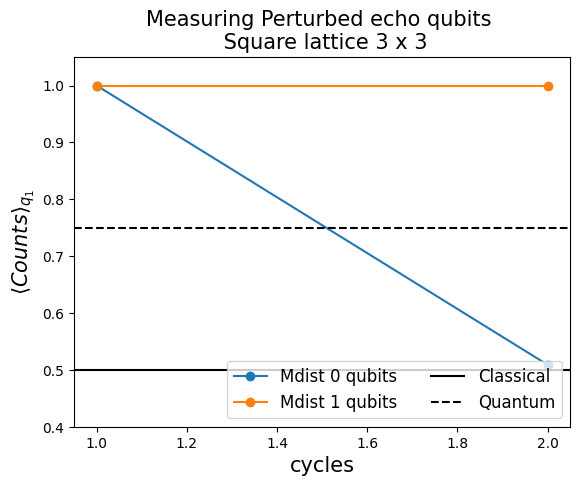

In [ ]:
fontsize_plot = 15
for key,values in classification.items():
    if key ==0:
        plt.plot(range(depths), count_avg_un_p_s[key], "-*", color="black", label="Unperturbed")
    else:
        plt.plot(range(depths), count_avg_un_p_s[key], "-*", color="black")
    plt.plot(range(depths), count_avg_p_s[key], "-o", label=f"Mdist {key} qubits")

plt.axhline(1/2, label= "Classical", color = "black")
plt.axhline(3/4, linestyle = "--",label= "Quantum", color = "black")
plt.title(f"Measuring Perturbed echo qubits \n Square lattice {side} x {side}", fontsize= fontsize_plot)
plt.xlabel("cycles", fontsize= fontsize_plot)
plt.ylabel(r"$\langle Counts \rangle_{q_{1}}$", fontsize= fontsize_plot)
plt.legend(fontsize =fontsize_plot-3, loc="lower right", ncol=2)
plt.ylim(0.4, 1.05)

In [ ]:
import pathlib, sys
sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
from src.analysis import sweep_perturbation_strength
from src.circuits import make_line_qubits
from src.plotting import plot_echo_signal_vs_theta

In [ ]:
qubits = make_line_qubits(3)
df = sweep_perturbation_strength(qubits, depth=4, theta_values=np.linspace(0, np.pi, 11))
df

In [ ]:
plot_echo_signal_vs_theta(df);